## 三、从零搭建函数逼近

### 3.1 数据生成：带噪声的正弦波

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def generate_data(num_points, noise_std=0.1):
    """生成带高斯噪声的正弦波数据"""
    x_values = np.sort(np.random.uniform(0, 2*np.pi, num_points))
    noise = np.random.normal(0, noise_std, num_points)
    y_values = np.sin(x_values) + noise
    return torch.FloatTensor(x_values).reshape(-1, 1), \
        torch.FloatTensor(y_values).reshape(-1, 1)

# 生成 200 个训练点
x_train, y_train = generate_data(num_points=200, noise_std=0.1)

### 3.2 模型：最简单的 MLP

In [2]:
class SimpleNN(nn.Module):
    """单隐藏层 MLP: 1 → 50 → 1"""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 50)
        self.activation = nn.SiLU()
        self.fc2 = nn.Linear(50, 1)

    def forward(self, x):
        return self.fc2(self.activation(self.fc1(x)))

### 3.3 训练阶段一：Adam 快速下降

In [18]:
# 初始化模型
model = SimpleNN()
criterion = nn.MSELoss()

# ── 阶段一：Adam 快速下降 ──
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
num_epochs_adam = 2000
loss_history_adam = []

for epoch in tqdm(range(num_epochs_adam), desc="Adam 训练"):
    optimizer_adam.zero_grad()
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    optimizer_adam.step()
    loss_history_adam.append(loss.item())

print(f"Adam 最终损失：{loss_history_adam[-1]:.6e}")


Adam 训练: 100%|██████████| 2000/2000 [00:09<00:00, 202.08it/s]

Adam 最终损失：1.684367e-02


### 3.4 训练阶段二：L-BFGS 精调

In [19]:
# ── 阶段二：L-BFGS 精调 ──
optimizer_lbfgs = optim.LBFGS(model.parameters(),
                               lr=1.0,
                               max_iter=20,
                               history_size=50,
                               line_search_fn="strong_wolfe")

loss_history_lbfgs = []

def closure():
    """L-BFGS 需要的闭包：计算并返回 loss"""
    optimizer_lbfgs.zero_grad()
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    loss.backward()
    loss_history_lbfgs.append(loss.item())
    return loss

for step in tqdm(range(100), desc="L-BFGS 精调"):
    optimizer_lbfgs.step(closure)

print(f"L-BFGS 最终损失：{loss_history_lbfgs[-1]:.6e}")

L-BFGS 精调: 100%|██████████| 100/100 [00:00<00:00, 104.87it/s]

L-BFGS 最终损失：9.902571e-03


### 3.5 结果对比

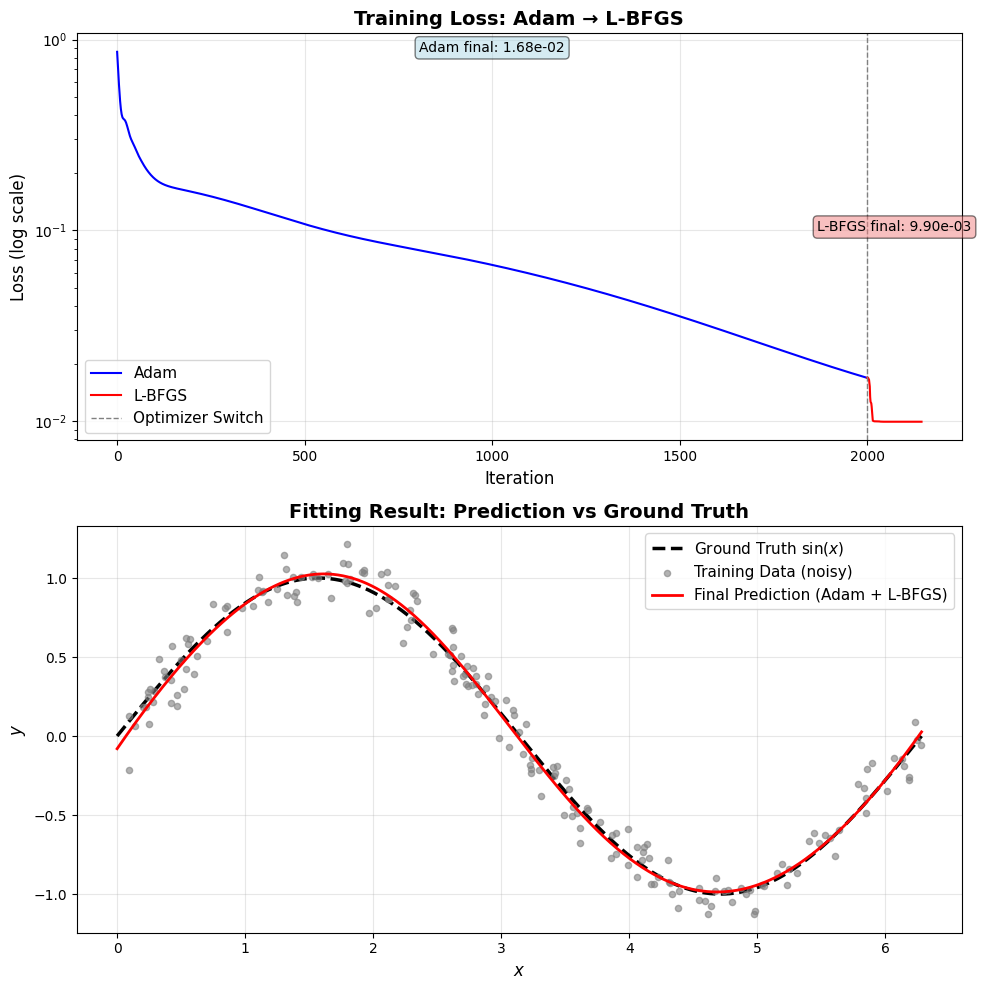


训练性能总结
Adam 最终损失：        1.684367e-02
L-BFGS 最终损失：      9.902571e-03
改进倍数：             1.70x

测试集 MSE：           5.481790e-04
测试集 MAE：           1.856443e-02


In [ ]:
# ── Visualization: Training Results Comparison ──
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# ========== Top Plot: Loss Curves Comparison ==========
axes[0].semilogy(range(len(loss_history_adam)), loss_history_adam, 
                 'b-', linewidth=1.5, label='Adam')
# L-BFGS loss curve starts from where Adam ends
lbfgs_offset = len(loss_history_adam)
axes[0].semilogy(range(lbfgs_offset, lbfgs_offset + len(loss_history_lbfgs)), 
                 loss_history_lbfgs, 'r-', linewidth=1.5, label='L-BFGS')
axes[0].axvline(x=lbfgs_offset, color='gray', linestyle='--', 
                linewidth=1, label='Optimizer Switch')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Loss (log scale)', fontsize=12)
axes[0].set_title('Training Loss: Adam → L-BFGS', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Add text annotations
axes[0].text(lbfgs_offset/2, max(loss_history_adam), 
             f'Adam final: {loss_history_adam[-1]:.2e}', 
             ha='center', fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[0].text(lbfgs_offset + len(loss_history_lbfgs)/2, min(loss_history_lbfgs)*10, 
             f'L-BFGS final: {loss_history_lbfgs[-1]:.2e}', 
             ha='center', fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# ========== Bottom Plot: Prediction vs Ground Truth ==========
# Generate dense test points
x_test = torch.linspace(0, 2*np.pi, 500).reshape(-1, 1)
y_test_true = torch.sin(x_test)

# Model prediction
model.eval()
with torch.no_grad():
    y_pred_final = model(x_test)

# Plot comparison
axes[1].plot(x_test.numpy(), y_test_true.numpy(), 'k--', 
             label='Ground Truth $\sin(x)$', linewidth=2.5, zorder=2)
axes[1].scatter(x_train.numpy(), y_train.numpy(), c='gray', 
                s=20, alpha=0.6, label='Training Data (noisy)', zorder=3)
axes[1].plot(x_test.numpy(), y_pred_final.numpy(), 'r-', 
             label='Final Prediction (Adam + L-BFGS)', linewidth=2, zorder=4)
axes[1].set_xlabel('$x$', fontsize=12)
axes[1].set_ylabel('$y$', fontsize=12)
axes[1].set_title('Fitting Result: Prediction vs Ground Truth', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== 输出性能指标 ==========
mse_final = criterion(y_pred_final, y_test_true).item()
mae_final = torch.mean(torch.abs(y_pred_final - y_test_true)).item()

print("\n" + "="*50)
print("训练性能总结")
print("="*50)
print(f"Adam 最终损失：        {loss_history_adam[-1]:.6e}")
print(f"L-BFGS 最终损失：      {loss_history_lbfgs[-1]:.6e}")
print(f"改进倍数：             {loss_history_adam[-1] / loss_history_lbfgs[-1]:.2f}x")
print(f"\n测试集 MSE：           {mse_final:.6e}")
print(f"测试集 MAE：           {mae_final:.6e}")
print("="*50)


## 四、自动微分：PINN 的心脏

### 4.2 计算图

手动实现（简化版）：

In [ ]:
# 手动实现自动微分（简化版）
class Tensor:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        out = Tensor(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        out.grad = 1.0
        for v in sorted(self._topo(), key=lambda v: v.data):
            v._backward()

### 4.3 PyTorch 的 autograd

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*x**2 - x + 1
y.backward()
print(x.grad)  # 输出：19.0（3×4 + 4×2 - 1 = 19）

## 六、课后练习参考答案

### 练习 1：目标函数 $\sin(3x) \cdot \cos(x)$

100%|██████████| 3000/3000 [00:14<00:00, 207.95it/s]


Adam loss: 1.112498e-01


100%|██████████| 100/100 [00:14<00:00,  6.75it/s]


L-BFGS loss: 2.862884e-03


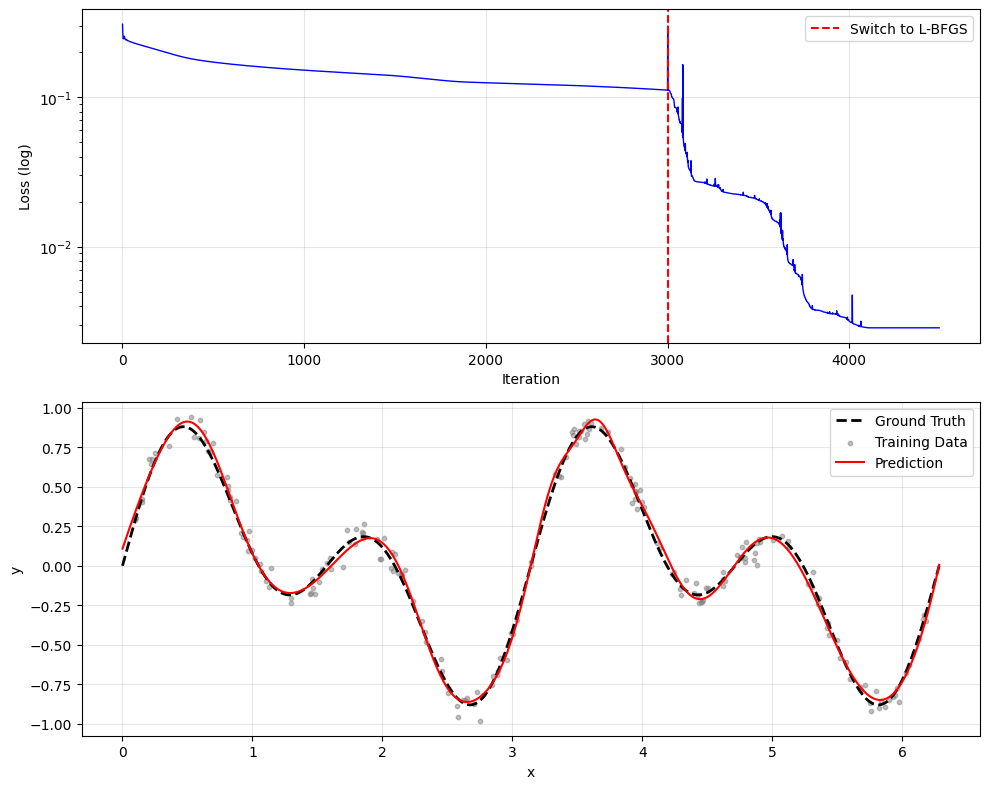

In [ ]:
def generate_data(num_points, noise_std=0.05):
    x = np.sort(np.random.uniform(0, 2*np.pi, num_points))
    noise = np.random.normal(0, noise_std, num_points)
    y = np.sin(3*x) * np.cos(x) + noise
    return torch.FloatTensor(x).reshape(-1, 1), torch.FloatTensor(y).reshape(-1, 1)

x_train, y_train = generate_data(200)

model = SimpleNN()
criterion = nn.MSELoss()
loss_history = []

# Adam 阶段
opt = optim.Adam(model.parameters(), lr=1e-3)
for _ in tqdm(range(3000)):
    opt.zero_grad()
    loss = criterion(model(x_train), y_train)
    loss.backward()
    opt.step()
    loss_history.append(loss.item())
print(f"Adam loss: {loss.item():.6e}")

# L-BFGS 精调
adam_end = len(loss_history)
opt_lbfgs = optim.LBFGS(model.parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe")
def closure():
    opt_lbfgs.zero_grad()
    loss = criterion(model(x_train), y_train)
    loss.backward()
    loss_history.append(loss.item())
    return loss
for _ in tqdm(range(100)):
    opt_lbfgs.step(closure)
print(f"L-BFGS loss: {criterion(model(x_train), y_train).item():.6e}")

# 可视化
x_test = torch.linspace(0, 2*np.pi, 500).reshape(-1, 1)
y_true = torch.sin(3*x_test) * torch.cos(x_test)
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.semilogy(loss_history, 'b-', linewidth=1)
ax1.axvline(adam_end, color='r', linestyle='--', label='Switch to L-BFGS')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss (log)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(x_test.numpy(), y_true.numpy(), 'k--', label='Ground Truth', linewidth=2)
ax2.scatter(x_train.numpy(), y_train.numpy(), c='gray', s=10, alpha=0.5, label='Training Data')
ax2.plot(x_test.numpy(), y_pred.numpy(), 'r-', label='Prediction', linewidth=1.5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 练习 2：ReLU vs SiLU

100%|██████████| 2000/2000 [00:09<00:00, 210.08it/s]


Adam loss: 4.887193e-02


100%|██████████| 100/100 [00:05<00:00, 17.47it/s]


L-BFGS loss: 4.383112e-02


100%|██████████| 2000/2000 [00:07<00:00, 277.09it/s]


Adam loss: 1.386794e-01


100%|██████████| 100/100 [00:16<00:00,  6.16it/s]


L-BFGS loss: 2.034676e-02
ReLU 光滑度: 4.003960e-03
SiLU 光滑度: 5.100940e-03
ReLU 折线程度是 SiLU 的 1 倍


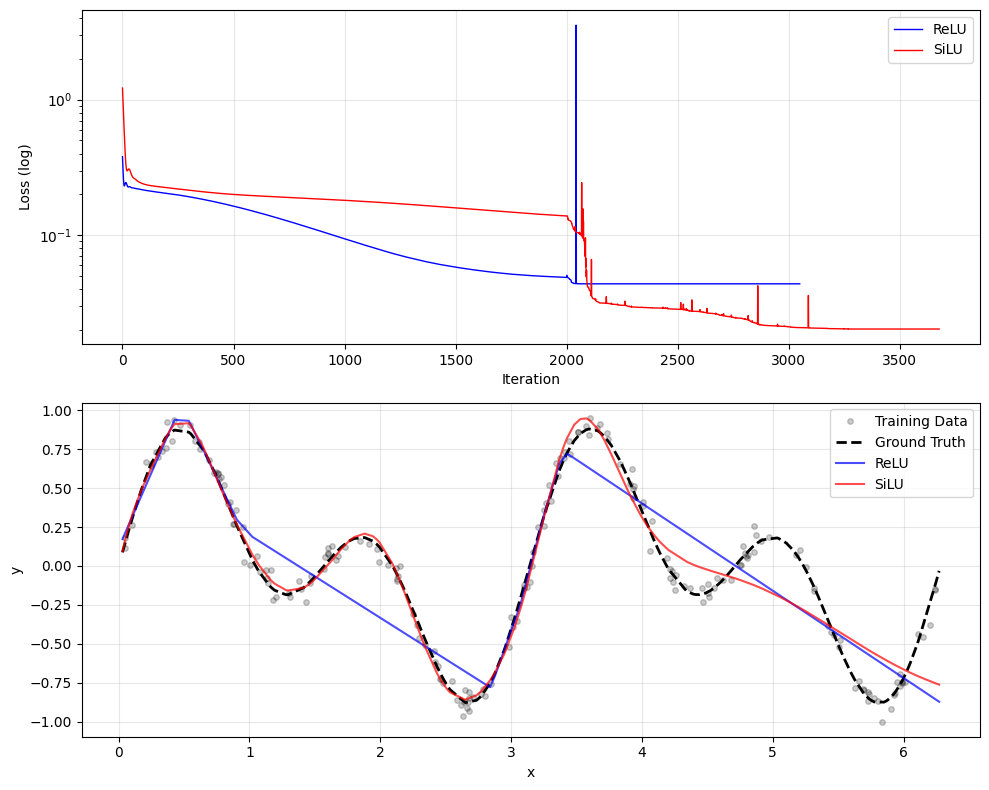

In [40]:
class ReLU_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 50)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(50, 1)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

def generate_data(num_points, noise_std=0.05):
    x = np.sort(np.random.uniform(0, 2*np.pi, num_points))
    noise = np.random.normal(0, noise_std, num_points)
    y = np.sin(3*x) * np.cos(x) + noise
    return torch.FloatTensor(x).reshape(-1, 1), torch.FloatTensor(y).reshape(-1, 1)

x_train, y_train = generate_data(200)
x_true, y_true = generate_data(200, noise_std=0.0)

criterion = nn.MSELoss()
# 训练 ReLU 模型
model_relu = ReLU_NN()
loss_relu = []
# Adam 阶段
opt = optim.Adam(model_relu.parameters(), lr=1e-3)
for _ in tqdm(range(2000)):
    opt.zero_grad()
    loss = criterion(model_relu(x_train), y_train)
    loss.backward()
    opt.step()
    loss_relu.append(loss.item())
print(f"Adam loss: {loss_relu[-1]:.6e}")

# L-BFGS 精调
adam_end = len(loss_relu)
opt_lbfgs = optim.LBFGS(model_relu.parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe")
def closure():
    opt_lbfgs.zero_grad()
    loss = criterion(model_relu(x_train), y_train)
    loss.backward()
    loss_relu.append(loss.item())
    return loss
for _ in tqdm(range(100)):
    opt_lbfgs.step(closure)
print(f"L-BFGS loss: {loss_relu[-1]:.6e}")

# 训练 SiLU 模型
model_silu = SimpleNN()
loss_silu = []
# Adam 阶段
opt = optim.Adam(model_silu.parameters(), lr=1e-3)
for _ in tqdm(range(2000)):
    opt.zero_grad()
    loss = criterion(model_silu(x_train), y_train)
    loss.backward()
    opt.step()
    loss_silu.append(loss.item())
print(f"Adam loss: {loss_silu[-1]:.6e}")

# L-BFGS 精调
adam_end = len(loss_silu)
opt_lbfgs = optim.LBFGS(model_silu.parameters(), lr=1.0, max_iter=20, line_search_fn="strong_wolfe")
def closure():
    opt_lbfgs.zero_grad()
    loss = criterion(model_silu(x_train), y_train)
    loss.backward()
    loss_silu.append(loss.item())
    return loss
for _ in tqdm(range(100)):
    opt_lbfgs.step(closure)
print(f"L-BFGS loss: {loss_silu[-1]:.6e}")

# 计算光滑度
with torch.no_grad():
    y_relu = model_relu(x_true)
    y_silu = model_silu(x_true)
d2y_relu = torch.diff(torch.diff(y_relu.squeeze()))
d2y_silu = torch.diff(torch.diff(y_silu.squeeze()))
roughness_relu = (d2y_relu**2).mean().item()
roughness_silu = (d2y_silu**2).mean().item()

print(f"ReLU 光滑度: {roughness_relu:.6e}")
print(f"SiLU 光滑度: {roughness_silu:.6e}")
print(f"ReLU 折线程度是 SiLU 的 {roughness_relu/roughness_silu:.0f} 倍")

# 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.semilogy(loss_relu, 'b-', label='ReLU', linewidth=1)
ax1.semilogy(loss_silu, 'r-', label='SiLU', linewidth=1)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss (log)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(x_train.numpy(), y_train.numpy(), 'ko',
         label='Training Data', markersize=4, alpha=0.2)
ax2.plot(x_true.numpy(), y_true.numpy(), 'k--',
         label='Ground Truth', linewidth=2)
ax2.plot(x_true.numpy(), y_relu.numpy(), 'b-',
         label='ReLU', linewidth=1.5, alpha=0.7)
ax2.plot(x_true.numpy(), y_silu.numpy(), 'r-',
         label='SiLU', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

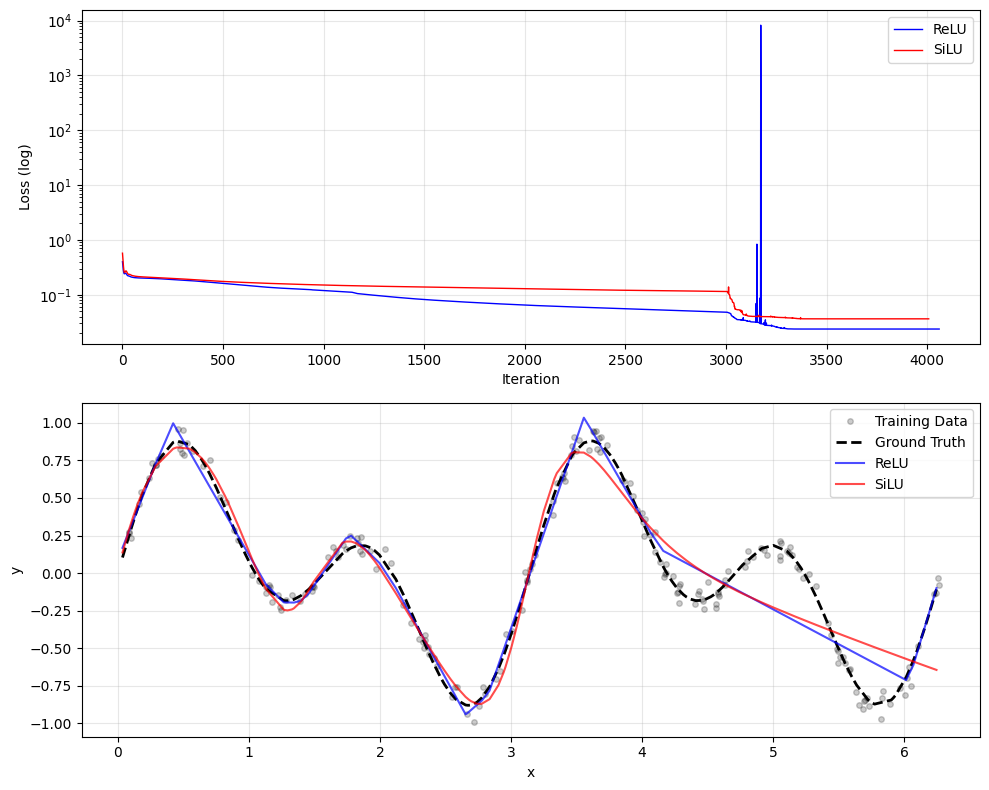

In [37]:

# 可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.semilogy(loss_relu, 'b-', label='ReLU', linewidth=1)
ax1.semilogy(loss_silu, 'r-', label='SiLU', linewidth=1)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss (log)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(x_train.numpy(), y_train.numpy(), 'ko',
         label='Training Data', markersize=4, alpha=0.2)
ax2.plot(x_true.numpy(), y_true.numpy(), 'k--',
         label='Ground Truth', linewidth=2)
ax2.plot(x_true.numpy(), y_relu.numpy(), 'b-',
         label='ReLU', linewidth=1.5, alpha=0.7)
ax2.plot(x_true.numpy(), y_silu.numpy(), 'r-',
         label='SiLU', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 练习 3：手动计算一阶和二阶导数

In [34]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.sin(x)

# 一阶导数：f'(x) = cos(x)
dy_dx = torch.autograd.grad(y, x, create_graph=True)[0]
print(f"f'(1) 自动微分 = {dy_dx.item():.10f}")
print(f"cos(1) 解析值  = {torch.cos(torch.tensor(1.0)).item():.10f}")

# 二阶导数：f''(x) = -sin(x)
d2y_dx2 = torch.autograd.grad(dy_dx, x)[0]
print(f"f''(1) 自动微分 = {d2y_dx2.item():.10f}")
print(f"-sin(1) 解析值  = {-torch.sin(torch.tensor(1.0)).item():.10f}")

f'(1) 自动微分 = 0.5403023362
cos(1) 解析值  = 0.5403023362
f''(1) 自动微分 = -0.8414709568
-sin(1) 解析值  = -0.8414709568
